In [1]:
here::i_am("rna_atac/differential/RNA.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))


BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 21

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”


In [2]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

# outdir
args$outdir = file.path(io$basedir, 'results/rna_atac/differential/markers/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [3]:
# Load meta
meta = fread(args$metadata)

#### Load Data

In [4]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [5]:
# Prepare mofa umap
umap.dt = meta[,c('cell', 'UMAP1', 'UMAP2', 'genotype')] %>% 
    .[match(colnames(rna.sce), cell),]

In [6]:
head(meta)

cell,barcode,sample,nFeature_RNA,nCount_RNA,mitochondrial_percent_RNA,ribosomal_percent_RNA,alias,day,genotype,⋯,celltype_extended.score_mnn,stage.mapped_mnn,cellstage.score_mnn,closest.cell_mnn,celltype_genotype,celltype_extended_genotype,UMAP1,UMAP2,mofa_cluster,celltype_v1
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>
1A_Eo_DEG_G9_day3#AAACAGCCAGCAAGAT-1,AAACAGCCAGCAAGAT-1,1A_Eo_DEG_G9_day3,6110,22923,6.09,10.15,day3_WT_rep1,D3,WT,⋯,0.60,E7.25,0.56,cell_29706,Epiblast-WT,Epiblast-WT,-6.742873,-4.051344,7,Primitive_Streak
1A_Eo_DEG_G9_day3#AAACAGCCAGCACCAT-1,AAACAGCCAGCACCAT-1,1A_Eo_DEG_G9_day3,4201,10794,6.57,7.38,day3_WT_rep1,D3,WT,⋯,0.96,E7.0,0.44,cell_79342,Primitive_Streak-WT,Primitive_Streak-WT,-5.456130,-2.490946,2,Primitive_Streak
1A_Eo_DEG_G9_day3#AAACATGCAAGTAAGC-1,AAACATGCAAGTAAGC-1,1A_Eo_DEG_G9_day3,3659,8745,5.74,11.92,day3_WT_rep1,D3,WT,⋯,0.72,E7.25,0.56,cell_41792,Epiblast-WT,Epiblast-WT,-6.348085,-4.264254,7,Primitive_Streak
1A_Eo_DEG_G9_day3#AAACATGCAATATACC-1,AAACATGCAATATACC-1,1A_Eo_DEG_G9_day3,3640,8461,3.70,7.21,day3_WT_rep1,D3,WT,⋯,0.84,E7.25,0.60,cell_5664,Primitive_Streak-WT,Primitive_Streak-WT,-6.044776,-2.846936,2,Primitive_Streak
1A_Eo_DEG_G9_day3#AAACATGCAATCCTGA-1,AAACATGCAATCCTGA-1,1A_Eo_DEG_G9_day3,3632,8276,4.60,8.16,day3_WT_rep1,D3,WT,⋯,0.60,E7.25,0.80,cell_81702,Primitive_Streak-WT,Primitive_Streak-WT,-4.960897,-3.201840,11,Primitive_Streak
1A_Eo_DEG_G9_day3#AAACATGCACTTAGGC-1,AAACATGCACTTAGGC-1,1A_Eo_DEG_G9_day3,4878,15676,7.34,8.97,day3_WT_rep1,D3,WT,⋯,0.84,E7.25,0.56,cell_88836,Primitive_Streak-WT,Primitive_Streak-WT,-5.634477,-2.450560,2,Primitive_Streak


In [7]:
names(opts$celltype_v1.colors)

[1] "Early_Mes_EOd"       "Primitive_Streak"    "HE"                 
 [4] "Posterior_Mes"       "Mesenchyme"          "Early_Mes_EOi"      
 [7] "Allantois"           "Allantois_Precursor" "HE_Precursor"       
[10] "Endothelium"         "Blood_Progenitor"

In [8]:
celltype_proportions = meta %>% copy() %>%
    .[,Ntot := .N, by = c('day', 'genotype')] %>%
    .[,proportion := .N/Ntot, by = c('day', 'genotype', 'celltype_v1')] %>% 
    unique(by = c('day', 'genotype', 'celltype_v1')) %>% 
   .[,celltype_v1 := factor(celltype_v1, levels = rev(c('Primitive_Streak', 'Early_Mes_EOd', 
                                                    'HE_Precursor','Blood_Progenitor', 'HE','Endothelium',   'Early_Mes_EOi',
                                                     'Allantois','Allantois_Precursor','Posterior_Mes', 'Mesenchyme'
                                                     )))] %>% 
    .[,day := factor(day, levels = rev(names(opts$days.colors)))] %>% 
    .[, c('day', 'genotype', 'celltype_v1', 'proportion')]

all = expand.grid(unique(celltype_proportions$day), unique(celltype_proportions$genotype), unique(celltype_proportions$celltype_v1)) %>%
    setnames(c('day', 'genotype', 'celltype_v1'))

celltype_proportions = merge(celltype_proportions, all, by = c('day', 'genotype', 'celltype_v1'), all=TRUE) %>% 
    .[,proportion:= ifelse(is.na(proportion), 0, proportion)] %>%
    .[,proportion:= ifelse(genotype=='KO' & day == 'D3', .[genotype=='WT' & day == 'D3', proportion], proportion)] %>% 
    .[,genotype:=gsub('KO', 'Eomes KD', genotype)] %>%
    .[,genotype:=factor(genotype, levels=c('WT', 'Eomes KD'))]

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


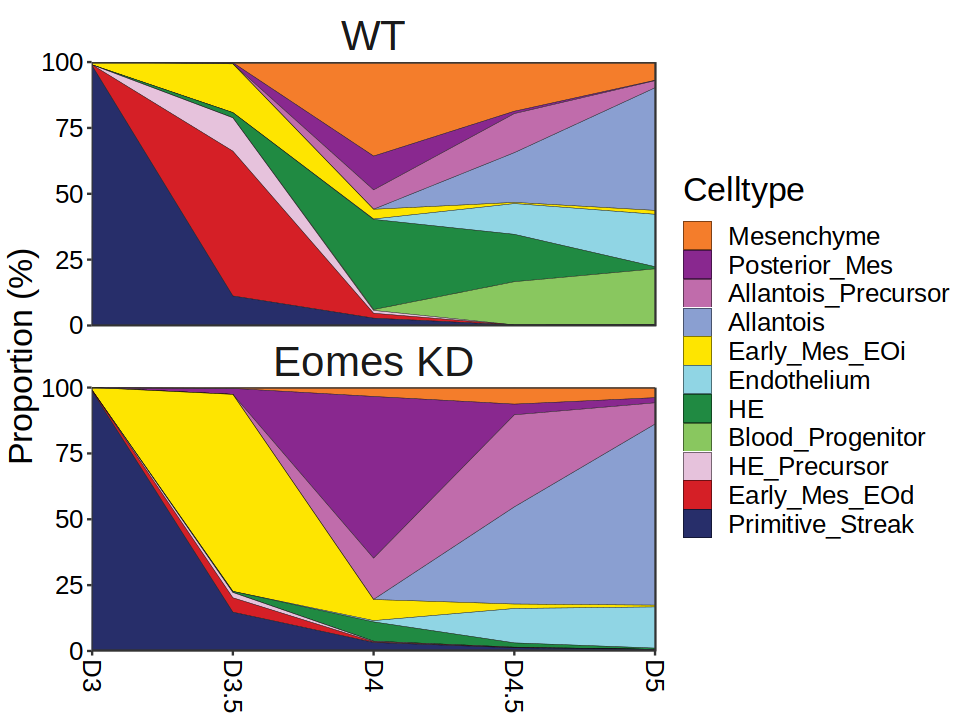

In [9]:
options(repr.plot.width=8, repr.plot.height=6)
p = ggplot(celltype_proportions, aes(day, proportion*100, group=celltype_v1, fill=celltype_v1)) + 
    geom_area(color='black', size=0.1) + 
    scale_fill_manual(values=opts$celltype_v1.colors, name = 'Celltype') + 
    facet_wrap(~genotype, ncol=1) +
    ylab('Proportion (%)') +
      scale_x_discrete(expand = c(0, 0)) +
      scale_y_continuous(expand = c(0, 0)) +
    theme_bw() + 
    theme(strip.background = element_blank(),
          strip.text = element_text(size=25),
          axis.text = element_text(size=15, color='black'),
          axis.text.x = element_text(angle=-90, hjust=0, vjust=0.5),
          axis.title.y = element_text(size=20),
          axis.title.x = element_blank(),
          legend.text = element_text(size=15, color='black'),
          legend.title = element_text(size=20))
p

### Differential Abundance testing

In [11]:
# Remove D3
meta = meta[day != 'D3']

# Prepare mofa umap
umap.mtx = meta[,c('cell', 'UMAP1', 'UMAP2')] %>% 
    as.data.frame(.) %>% 
    tibble::column_to_rownames('cell') %>%
    as.matrix()

#Get MOFA factors
mofa = fread(file.path(io$basedir, 'results/rna_atac/dimensionality_reduction/mofa/MOFA_factors.txt.gz')) %>% 
    .[match(meta$cell, cell),] %>% 
    as.data.frame() %>% tibble::column_to_rownames('cell') %>% 
    as.matrix

# subset SCE
rna.sce = rna.sce[,meta$cell]

In [12]:
# Add mofa factors
reducedDims(rna.sce)$mofa = mofa
# Add mofa umap
reducedDims(rna.sce)$mofa_umap = umap.mtx[match(colnames(rna.sce), rownames(umap.mtx)),]

In [13]:
neighbors = BiocNeighbors::findKNN(mofa, 300, BPPARAM = BPPARAM)

In [14]:
id_gt = meta %>% copy() %>% 
    .[,'genotype'] %>% 
    .[,value:=.I]

In [31]:
ratios = as.data.table(neighbors$index) %>% 
    .[,index := .I] %>% 
    melt(id.vars = 'index') %>%
    .[,variable:=NULL] %>% 
    merge(id_gt, by='value') %>% 
    .[,`:=`(KO = sum(genotype=='KO'), WT = sum(genotype=='WT')), by=index] %>% 
    .[,ratio := log2(KO/WT)] %>%
    unique(by='index') %>% 
    .[,c('index', 'ratio')] %>%
    .[order(index)] %>% 
    .[,ratio:=ifelse(ratio==-Inf, -9, ifelse(ratio==Inf, 9, ratio))]

In [32]:
head(ratios)

index,ratio
<int>,<dbl>
1,-7.21916852
2,-0.70626880
3,0.03847415
4,-3.52356196
5,-2.87446912
6,-9.00000000


In [19]:
meta_ratio = cbind(meta, ratios) %>%
    .[,celltype_v1 := factor(celltype_v1, levels = c('Primitive_Streak', 'Early_Mes_EOd', 
                                                    'HE_Precursor','Blood_Progenitor', 'HE','Endothelium',   'Early_Mes_EOi',
                                                     'Allantois','Allantois_Precursor','Posterior_Mes', 'Mesenchyme'
                                                     ))]

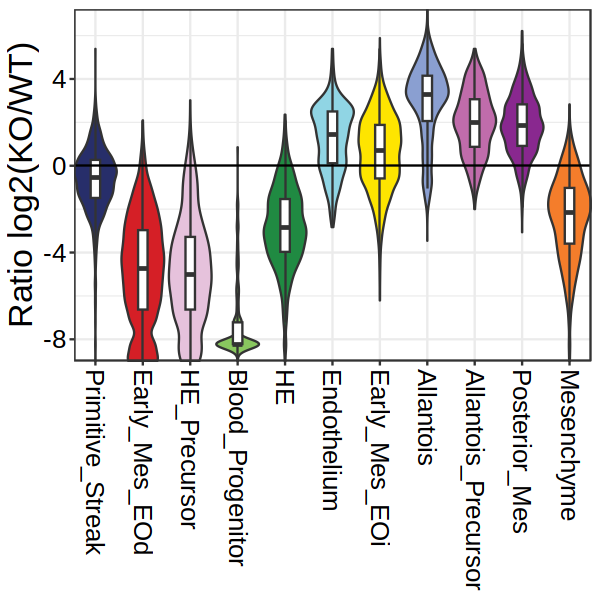

In [20]:
options(repr.plot.width=5, repr.plot.height=5)
ggplot(meta_ratio, aes(celltype_v1, ratio, fill=celltype_v1)) + 
    geom_violin(scale = "width") + 
    geom_boxplot(width=0.2, fill='white', outlier.shape=NA) +
    geom_hline(yintercept = 0) + 
    scale_fill_manual(values=opts$celltype_v1.colors, name = 'Celltype') + 
    ylab('Ratio log2(KO/WT)') +
      scale_x_discrete(expand = c(0, 0)) +
      scale_y_continuous(expand = c(0, 0)) +
    theme_bw() + 
    theme(strip.background = element_blank(),
          strip.text = element_text(size=25),
          axis.text = element_text(size=15, color='black'),
          axis.text.x = element_text(angle=-90, hjust=0, vjust=0.5),
          axis.title.y = element_text(size=20),
          axis.title.x = element_blank(),
          legend.text = element_text(size=15, color='black'),
          legend.title = element_text(size=20),
          legend.position = 'none')

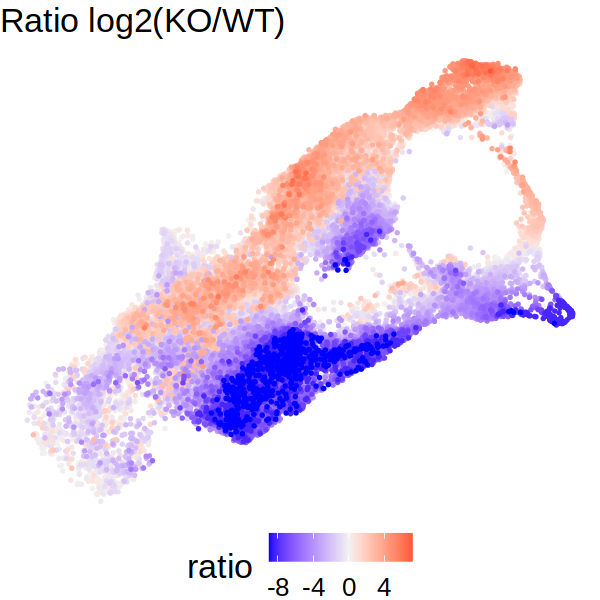

In [21]:
options(repr.plot.width=5, repr.plot.height=5)
ggplot(meta_ratio[order(abs(ratio))], aes(UMAP1, UMAP2, color=ratio)) + 
    geom_point(size=0.5) +
    scale_color_gradient2(low='blue', mid='grey95', high='red', name='ratio') +
    ggtitle('Ratio log2(KO/WT)') + 
    theme_void() + 
    theme(plot.title = element_text(size=20),
          legend.text = element_text(size=15, color='black'),
          legend.title = element_text(size=20),
          legend.position = 'bottom')

# Normalising for nr of cells per genotype
Maybe should also normalise within samples?

In [81]:
neighbors = BiocNeighbors::findKNN(mofa, 100, BPPARAM = BPPARAM)

In [82]:
id_gt = meta %>% copy() %>% 
    .[,'genotype'] %>% 
    .[,value:=.I]

In [83]:
KOtot = nrow(meta[genotype=='KO'])
WTtot = nrow(meta[genotype=='WT'])
ratios = as.data.table(neighbors$index) %>% 
    .[,index := .I] %>% 
    melt(id.vars = 'index') %>%
    .[,variable:=NULL] %>% 
    merge(id_gt, by='value') %>% 
    .[,`:=`(KO = sum(genotype=='KO')/KOtot, WT = sum(genotype=='WT')/WTtot), by=index] %>% 
    .[,ratio := log2(KO/WT)] %>%
    unique(by='index') %>% 
    .[,c('index', 'ratio')] %>%
    .[order(index)] %>% 
    .[,ratio:=ifelse(ratio==-Inf, -9, ifelse(ratio==Inf, 9, ratio))] %>% 
    .[]

In [84]:
meta_ratio = cbind(meta, ratios) %>%
    .[,celltype_v1 := factor(celltype_v1, levels = c('Primitive_Streak', 'Early_Mes_EOd', 
                                                    'HE_Precursor','Blood_Progenitor', 'HE','Endothelium',   'Early_Mes_EOi',
                                                     'Allantois','Allantois_Precursor','Posterior_Mes', 'Mesenchyme'
                                                     ))]

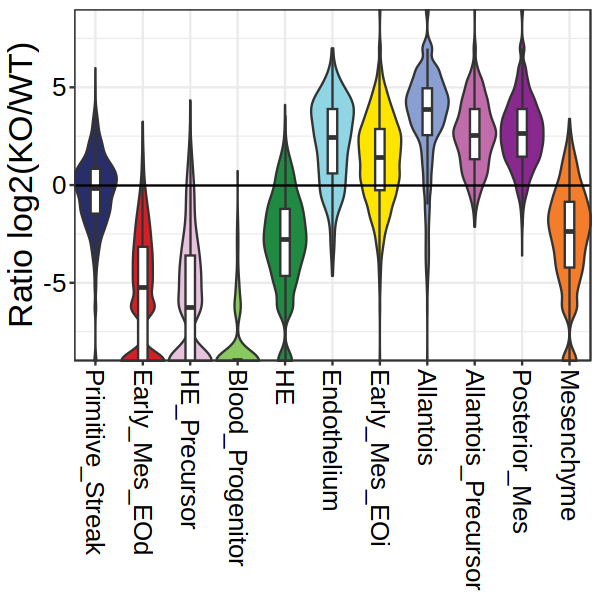

In [85]:
options(repr.plot.width=5, repr.plot.height=5)
ggplot(meta_ratio, aes(celltype_v1, ratio, fill=celltype_v1)) + 
    geom_violin(scale = "width") + 
    geom_boxplot(width=0.2, fill='white', outlier.shape=NA) +
    geom_hline(yintercept = 0) + 
    scale_fill_manual(values=opts$celltype_v1.colors, name = 'Celltype') + 
    ylab('Ratio log2(KO/WT)') +
      scale_x_discrete(expand = c(0, 0)) +
      scale_y_continuous(expand = c(0, 0)) +
    theme_bw() + 
    theme(strip.background = element_blank(),
          strip.text = element_text(size=25),
          axis.text = element_text(size=15, color='black'),
          axis.text.x = element_text(angle=-90, hjust=0, vjust=0.5),
          axis.title.y = element_text(size=20),
          axis.title.x = element_blank(),
          legend.text = element_text(size=15, color='black'),
          legend.title = element_text(size=20),
          legend.position = 'none')

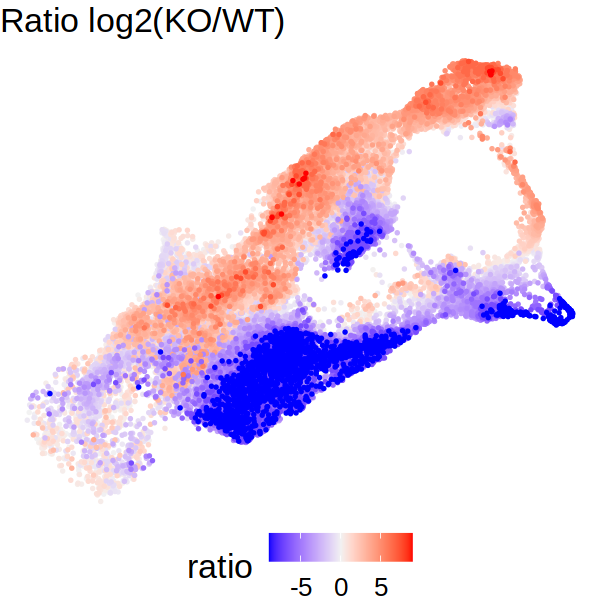

In [76]:
options(repr.plot.width=5, repr.plot.height=5)
ggplot(meta_ratio[order(abs(ratio))], aes(UMAP1, UMAP2, color=ratio)) + 
    geom_point(size=0.5) +
    scale_color_gradient2(low='blue', mid='grey95', high='red', name='ratio') +
    ggtitle('Ratio log2(KO/WT)') + 
    theme_void() + 
    theme(plot.title = element_text(size=20),
          legend.text = element_text(size=15, color='black'),
          legend.title = element_text(size=20),
          legend.position = 'bottom')